# APE07U2: Distribuciones Muestrales(TLC)-Grupo A

# Tarea 1

--- Parámetros Poblacionales Reales ---
Media (μ): 1.9919
Desviación Estándar (σ): 1.9859


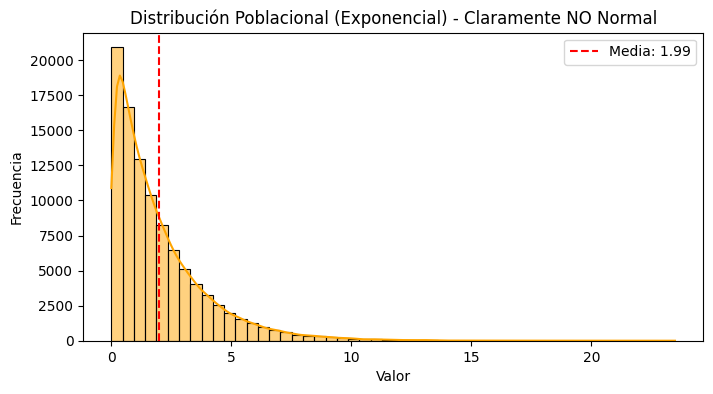

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creación de la Población "Universo"
np.random.seed(42)
poblacion_exponencial = np.random.exponential(scale=2.0, size=100000)

mu_pob = np.mean(poblacion_exponencial)
sigma_pob = np.std(poblacion_exponencial)

print("--- Parámetros Poblacionales Reales ---")
print(f"Media (μ): {mu_pob:.4f}")
print(f"Desviación Estándar (σ): {sigma_pob:.4f}")

plt.figure(figsize=(8, 4))
sns.histplot(poblacion_exponencial, bins=50, kde=True, color='orange')

plt.title("Distribución Poblacional (Exponencial) - Claramente NO Normal")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.axvline(mu_pob, color='red', linestyle='dashed', label=f'Media: {mu_pob:.2f}')
plt.legend()
plt.show()


# Tarea 2

--- Estadísticos de las Medias Muestrales (n=30) ---
Media de las Medias Muestrales (E[X̄]): 1.9923
Error Estándar Empírico (σ_x̄): 0.3653
Error Estándar Teórico (σ/√n): 0.3626


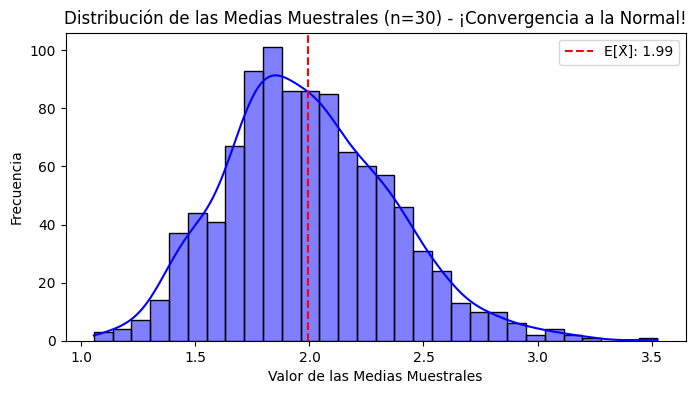

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parámetros de la simulación
tamaño_muestra = 30  # n
numero_muestras = 1000  # k

# Array para almacenar las medias de cada muestra
medias_muestrales = []

# Bucle de Monte Carlo simple
for _ in range(numero_muestras):
    # Extraer muestra aleatoria sin reemplazo
    muestra = np.random.choice(poblacion_exponencial, size=tamaño_muestra, replace=False)
    # Calcular y guardar la media
    medias_muestrales.append(np.mean(muestra))

# Estadísticos de la Distribución Muestral
media_de_medias = np.mean(medias_muestrales)
error_estandar_empirico = np.std(medias_muestrales)
error_estandar_teorico = sigma_pob / np.sqrt(tamaño_muestra)

print(f"--- Estadísticos de las Medias Muestrales (n={tamaño_muestra}) ---")
print(f"Media de las Medias Muestrales (E[X̄]): {media_de_medias:.4f}")
print(f"Error Estándar Empírico (σ_x̄): {error_estandar_empirico:.4f}")
print(f"Error Estándar Teórico (σ/√n): {error_estandar_teorico:.4f}")

# Visualización de la convergencia a la Normal
plt.figure(figsize=(8, 4))
sns.histplot(medias_muestrales, bins=30, kde=True, color='blue')
plt.title(f"Distribución de las Medias Muestrales (n={tamaño_muestra}) - ¡Convergencia a la Normal!")
plt.xlabel("Valor de las Medias Muestrales")
plt.ylabel("Frecuencia")
plt.axvline(media_de_medias, color='red', linestyle='dashed', label=f'E[X̄]: {media_de_medias:.2f}')
plt.legend()
plt.show()


# Tarea 3

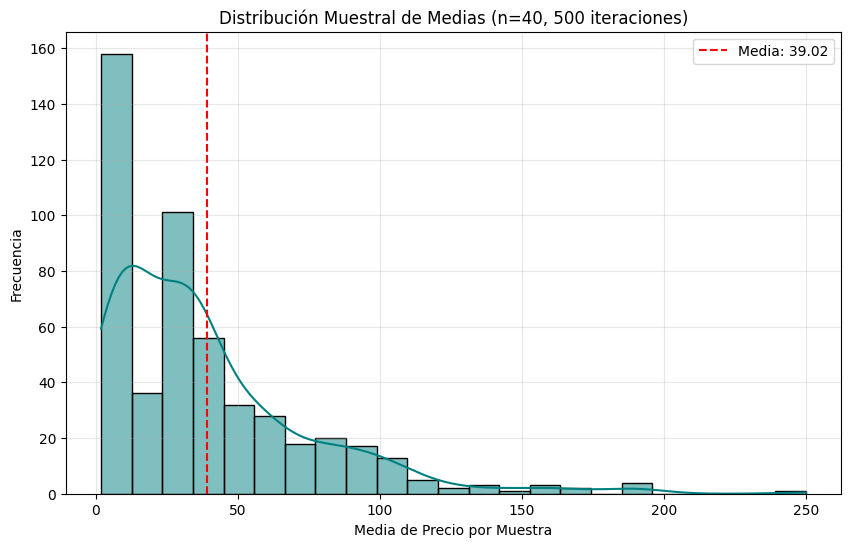

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nombres_columnas = ["Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
                    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
                    "Casa_Origen", "Casa_Destino", "Bolsa"]

df_regional = pd.read_csv("BVG_Acciones_export.csv", names=nombres_columnas, skiprows=1)

df_regional['Precio'] = pd.to_numeric(df_regional['Precio'], errors='coerce')
datos_precio = df_regional['Precio'].dropna()

# Creación del bucle
numero_muestras = 500
tamaño_muestra = 40
medias_muestrales = []

for _ in range(numero_muestras):
    muestra = datos_precio.sample(n=tamaño_muestra, replace=True)
    medias_muestrales.append(muestra.mean())

# Gráfico del histograma de las medias obtenidas
plt.figure(figsize=(10, 6))
sns.histplot(medias_muestrales, kde=True, color="teal")
plt.axvline(np.mean(medias_muestrales), color='red', linestyle='--', label=f'Media: {np.mean(medias_muestrales):.2f}')
plt.title(f'Distribución Muestral de Medias (n=40, {numero_muestras} iteraciones)')
plt.xlabel('Media de Precio por Muestra')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#### Dentro de lo que se establece en el Teorema del límite central, se deja en claro que mientras el tamaño de la muestra sea mayor a 30 y vaya aumentando, los datos, en un inicio dispersos, tenderán a seguir una distribución normal, una campana de Gauss, lo que provocará que se tenga un mayor control y seguridad de la información, logrando un mejor análisis e inferencia de datos. Permitiendo un modelo más seguro para tomar decisiones para un proyecto.

# Tarea 4

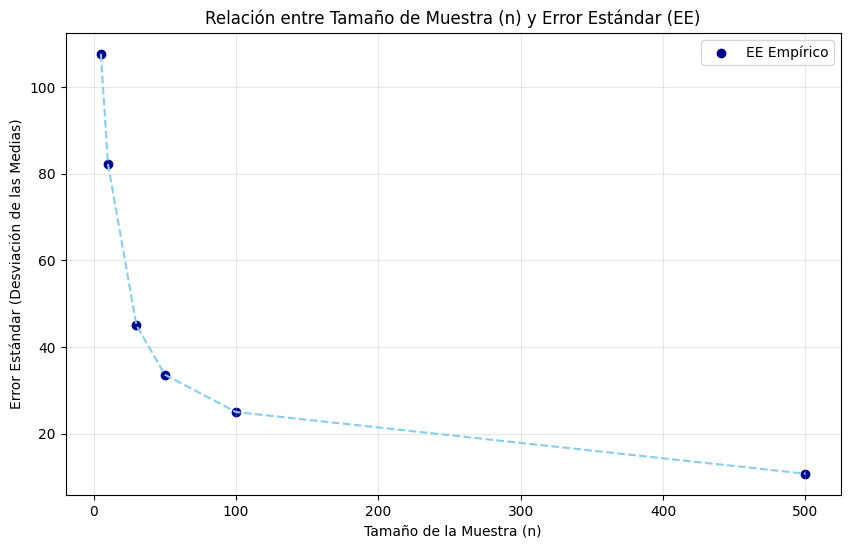

In [5]:
tamanos_n = [5, 10, 30, 50, 100, 500]
numero_iteraciones = 1000
errores_estandar_empiricos = []

# Iteración sobre los diferentes tamaños de muestra
for n in tamanos_n:
    medias_muestrales = []
    for _ in range(numero_iteraciones):
        muestra = datos_precio.sample(n=n, replace=True)
        medias_muestrales.append(muestra.mean())

    ee_empirico = np.std(medias_muestrales)
    errores_estandar_empiricos.append(ee_empirico)

# Generación del gráfico
plt.figure(figsize=(10, 6))
plt.scatter(tamanos_n, errores_estandar_empiricos, color='darkblue', label='EE Empírico')
plt.plot(tamanos_n, errores_estandar_empiricos, linestyle='--', color='skyblue')

plt.title('Relación entre Tamaño de Muestra (n) y Error Estándar (EE)')
plt.xlabel('Tamaño de la Muestra (n)')
plt.ylabel('Error Estándar (Desviación de las Medias)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


#### A medida que se aumenta el tamaño de la muestra se puede apreciar cómo la curva del gráfico empieza a decaer, se acerca a cero aunque nunca llega a él, esto por que los datos obtenidos nunca seran iguales, la desviación estandar no será cero. Esto significa que el error se reduce mientras más grande es una muestra, pero que llega un punto en el que es innecesario seguir haciéndolo pues nunca se eliminará por completo. Por lo tanto, se tendrían que gastar muchos recursos, entre ellos económicos, para lograr encoger el error lo más que se pueda, lo que no es viable económicamente porque de todas formas habrá un margen de error, por ende en este punto es mejor considerar cuál es el mínimo aceptable para el proyecto, en pro de ahorrar los recursos, en vez de tirarlos inútilmente. Se tiene que encontrar un equlibrio.

# Preguntas de control

### **1. Basado en la Tarea 1 y 2, ¿por qué el Teorema del Límite Central es considerado el puente matemático fundamental entre la probabilidad descriptiva y la inferencia estadística?**
#### El Teorema del Límite Central (TLC) es apodado el "puente" porque resuelve el problema más grande de la estadística: ¿Cómo se puede saber algo de una población entera si solo tengo una pequeña muestra?
#### En Probabilidad Descriptiva sólo se puede hablar de los datos que se tiene en la mano. Si la muestra no es "normal" (gaussiana), las herramientas son limitadas.
#### El Puente (TLC) establece que si se toman suficientes muestras, el promedio de esas muestras siempre formará una campana de Gauss, sin importar si los datos originales eran uniformes, exponenciales o totalmente caóticos.
#### El TLC "normaliza" la realidad. Gracias a él, podemos usar la distribución normal Z para casi todo. Por él se puede calcular el Error Estándar, que define cuánta variación esperar entre diferentes muestras. Sin él, no se podría calcular intervalos de confianza ni realizar pruebas de hipótesis, porque no habría una base matemática sólida para comparar los resultados

### **2. Demuestre con los resultados impresos en su consola de la Tarea 2, cómo se cumple la propiedad matemática fundamental de las distribuciones muestrales: E[X]=u**
#### La propiedad fundamental de las distribuciones muestrales dice que la media de la distribución muestral de las medias es igual a la media de la  población, de donde vienen las muestras, dado que la media muestral es un estimador insesgado de la media poblacional. Al ejecutar el código, a medida que se vaya sacando la media de cada una de las muestras, por mucho que algunas varían, el proceso de promediar una gran cantidad de muestras, en este caso 1000, hace que el resultado se vuelva igual al del parámetro real de la población, la media poblacional, y junto a un tamaño mayor a 30, también se reduce el error estándar. Por último, pese a que la media poblacional se mantiene fija, la muestra varía en función de sus datos y su variabilidad, dando casos en donde los datos están bastante dispersos, aquí se puede usar el teorema del límite central, siempre y cuando se tenga un tamaño de muestra >=30, para acercar la distribución de las medias muestrales a un distribución normal, más centrada en la media poblacional, ofreciendo un modelo preciso y seguro para obtener conclusiones válidas.

### **3. En la Tarea 4, al graficar la curva del Error Estándar frente n , ¿por qué la curva no desciende de forma lineal? Si usted como ingeniero requiere reducir el error estándar a la mitad, ¿cuántas veces debe incrementar el tamaño de la muestra?**
#### No desciende de forma lineal porque n no es proporcional respecto al error estándar y, sumado a que el tamaño de las muestras varía bastante, da como resultado a que se presenten cortes abruptos al graficar la curva, misma que se estabiliza a medida que n crece, sin llegar a cero. Por otra parte, para reducir el error estándar a la mitad, dada la fórmula presentada, tendríamos que tener un tamaño de muestra cuatro veces más grande que el desvío estándar para poder reducirlo a la mitad, todo gracias a la raíz cuadrada de la fórmula.

### **4. Históricamente, en estadística clásica se establece la regla de oro de n>=30 para asumir normalidad. Si la población regional que usted analizó en la Tarea 3 tiene una asimetría extrema (ej. distribución de Pareto de riquezas), ¿es suficiente un n=30 para que las medias muestrales se distribuyen normalmente? Justifique.**
#### Si la muestra tiene una asimetría extrema, el hecho de contar con n mayor a 30 no es suficiente como para que se cree un distribución normal, esto por la dispersión que tienen los datos, siendo necesario un mayor tamaño de la muestra para lograr la formación de una distribución normal, sin que los valores atípicos tengan tanto peso y creen un sesgo en la distribución de los datos.

### **5. Diferencie conceptual y operativamente los términos Desviación Estándar de una muestra individual y el Error Estándar de la Media calculado en sus simulaciones.**
#### En lo que respecta a la desviación estándar, esta mide que tan alejados están los datos respecto a su propia media, así como ayudar a obtener el error estándar, pues la mayoría del tiempo se necesitará de la desviación estándar muestral al no tener la poblacional. Por otro lado, el error estándar mide que tan alejado está el promedio muestral de los datos respecto a su promedio poblacional. El primer concepto mide la variabilidad individual, el segundo la variabilidad del promedio de los datos respecto a la realidad. La forma de operación de la desviación estándar viene dada por la fórmula:
#### $$s = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}$$

#### En nuestro dataset, muestra que los datos analizados están muy dispersos, por los valores que se presentan, mucho con valores bajos frente a unos pocos con valores bastante elevados. Por otra parte, la forma de operación del error estándar viene dada por la fórmula:

#### $$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{n}}$$


### Donde se cambia σ con s, si se desconoce la media poblacional. En nuestro dataset nos presenta que, si bien los datos están muy dispersos, a medida que tengamos un tamaño de muestra más grande, el promedio generado reduce cada vez más y más el error estándar, dándonos una información más confiable,


